**RDGY41710** Practical Session

**Ungraded task** on Gradient-weighted Class Activation Mapping (GradCAM)

June, 2024

In [ ]:
import sys
import torch
import os
import glob
import torch.utils.data
import subprocess
import cv2
import numpy as np
import matplotlib.image as img

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
from PIL import Image

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

In [ ]:
VAL_TRANSFORMS = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.0, 0.0, 0.0], [1.0, 1.0, 1.0])
])

Load a trained model from Pytorch model zoo https://pytorch.org/vision/stable/models.html


In [ ]:
from torchvision.models import ResNet18_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# RESNET 18
m_name = 'resnet'
model = torchvision.models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

model = model.to(device)

In [ ]:
# set model in evaluation mode
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
model.layer4[-1]

BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

### Register hook

**[register_full_backward_hook(hook, prepend=False)](https://https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook)**

This method registers a backward hook on the module, which means that the hook function will run when the backward() method is called.

```
hook(module, grad_input, grad_output) -> tuple(Tensor) or None
```

**[register_forward_hook(hook, *, prepend=False, with_kwargs=False)](https://https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook)**

The hook function runs in the forward pass, i.e., when the layer of interest processes its input and returns its outputs.

```
hook(module, args, output) -> None or modified output
```

In [ ]:
# defines two global scope variables to store our gradients and activations
gradients = None
activations = None

Create hook modules.

In [ ]:
def backward_hook(module, grad_input, grad_output):
  global gradients # refers to the variable in the global scope
  print('Backward hook running...')
  gradients = grad_output
  # In this case, we expect it to be torch.Size([batch size, 512, H, W])
  print(f'Gradients size: {gradients[0].size()}')
  # We need the 0 index because the tensor containing the gradients comes inside a one element tuple.

In [ ]:
def forward_hook(module, args, output):
  global activations # refers to the variable in the global scope
  print('Forward hook running...')
  activations = output
  # In this case, we expect it to be torch.Size([batch size, 512, H, W])
  print(f'Activations size: {activations.size()}')

Register the hooks on the last conv layer of interest.

In [ ]:
backward_hook = model.layer4[-1].register_full_backward_hook(backward_hook, prepend=False)
forward_hook = model.layer4[-1].register_forward_hook(forward_hook, prepend=False)

Import any image of your choice.

You can also download an image from [this link](https://github.com/EliSchwartz/imagenet-sample-images/tree/master)

A sample image link is included in the next block

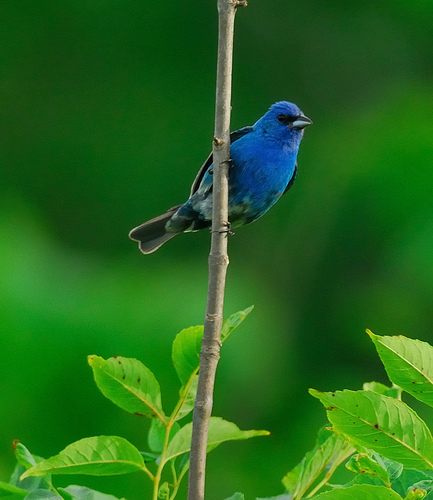

In [ ]:
# import a sample image
from io import BytesIO
import requests

# Example image 1
# response = requests.get('https://github.com/EliSchwartz/imagenet-sample-images/blob/master/n01580077_jay.JPEG?raw=true')
# Example image 2
response = requests.get('https://github.com/EliSchwartz/imagenet-sample-images/blob/master/n01537544_indigo_bunting.JPEG?raw=true')
img = Image.open(BytesIO(response.content))
img

Resize and preprocess the imported image

Hint: use the functions resize() from PIL, convert it to a numpy array, and preprocess_input()

In [ ]:
img.size

(433, 500)

In [ ]:
# since we're feeding only one image, it is a 3d tensor (3, H, W).
img = img.resize([224, 224])
x_test = VAL_TRANSFORMS(img)
# we need to unsqueeze to it has 4 dimensions (1, 3, H, W) as the model expects it to.
x_test = x_test.unsqueeze(0)

In [ ]:
x_test.shape

torch.Size([1, 3, 224, 224])

Retrieving the gradients and activations we need.

In [ ]:
# here we did the forward and the backward pass in one line.
loss = torch.ones(1,1000).to(device)
model(x_test.to(device)).backward(loss)

Forward hook running...
Activations size: torch.Size([1, 512, 7, 7])
Backward hook running...
Gradients size: torch.Size([1, 512, 7, 7])


In [ ]:
# pool the gradients across the channels
pooled_gradients = torch.mean(gradients[0], dim=[0, 2, 3])

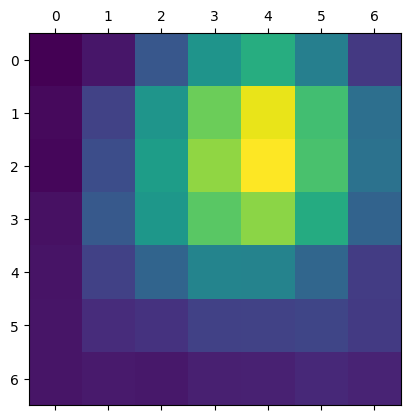

In [ ]:
# weight the channels by corresponding gradients
for i in range(activations.size()[1]):
    activations[:, i, :, :] *= pooled_gradients[i]

# average the channels of the activations
heatmap = torch.mean(activations, dim=1).squeeze()

# relu on top of the heatmap
heatmap = F.relu(heatmap)

# normalize the heatmap
heatmap /= torch.max(heatmap)

# draw the heatmap
plt.matshow(heatmap.detach().cpu())

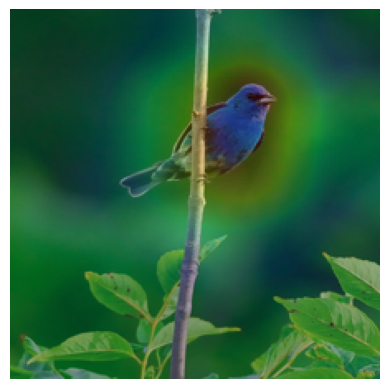

In [ ]:
from torchvision.transforms.functional import to_pil_image
from matplotlib import colormaps

# Create a figure and plot the first image
fig, ax = plt.subplots()
ax.axis('off') # removes the axis markers

# First plot the original image
ax.imshow(to_pil_image(torch.squeeze(x_test), mode='RGB'))

# Resize the heatmap to the same size as the input image and defines
# a resample algorithm for increasing image resolution
# we need heatmap.detach() because it can't be converted to numpy array while
# requiring gradients
overlay = to_pil_image(heatmap.detach(), mode='F').resize((224,224), resample=Image.BICUBIC)

# Apply any colormap you want
cmap = colormaps['jet']
overlay = (255 * cmap(np.asarray(overlay) ** 2)[:, :, :3]).astype(np.uint8)

# Plot the heatmap on the same axes,
# but with alpha < 1 (this defines the transparency of the heatmap)
ax.imshow(overlay, alpha=0.2, interpolation='nearest')

# Show the plot
plt.show()

### Use Existing Packages

* pytorch-grad-cam: https://github.com/jacobgil/pytorch-grad-cam

```
pip install grad-cam
```

* TorchCAM: https://github.com/frgfm/torch-cam

```
pip install torchcam
```